c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


0:	learn: 0.4539371	test: 0.4735418	best: 0.4735418 (0)	total: 139ms	remaining: 24.9s
50:	learn: 0.2742604	test: 0.2887971	best: 0.2887971 (50)	total: 244ms	remaining: 616ms
100:	learn: 0.1866757	test: 0.1978004	best: 0.1978004 (100)	total: 346ms	remaining: 270ms
150:	learn: 0.1356163	test: 0.1445206	best: 0.1445206 (150)	total: 459ms	remaining: 88.2ms
179:	learn: 0.1152679	test: 0.1232187	best: 0.1232187 (179)	total: 507ms	remaining: 0us

bestTest = 0.123218747
bestIteration = 179



c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(



🔹 CatBoost UTS Regression Metrics:
✅ R²: 0.9290
✅ RMSE: 0.1238
✅ MAE: 0.0741
✅ MAPE: 0.77%


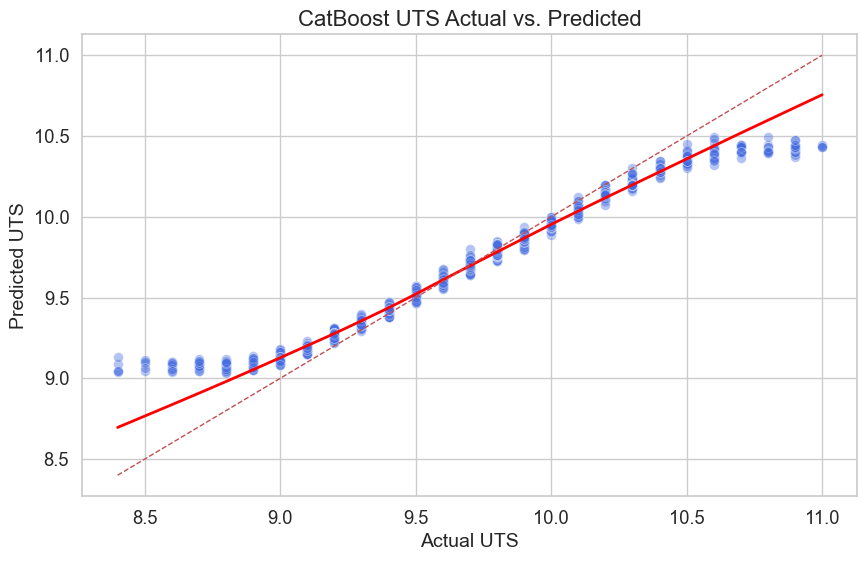

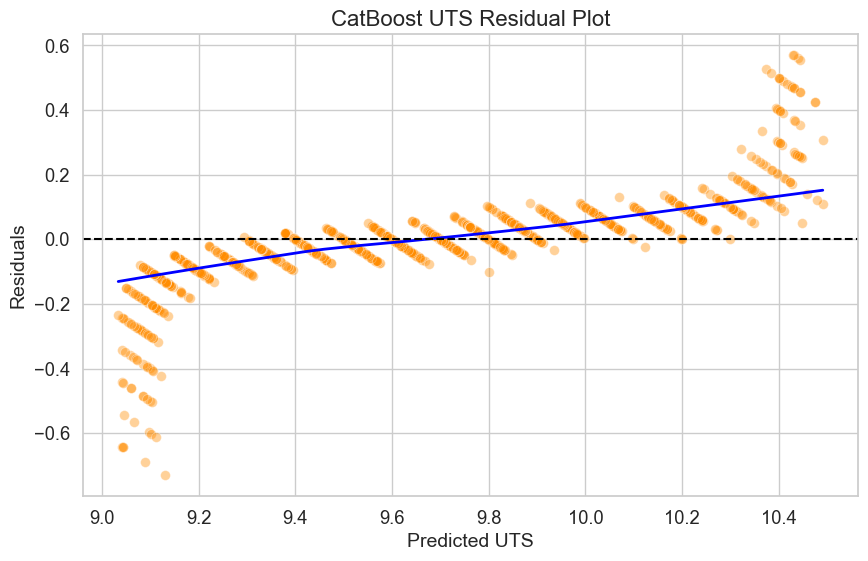

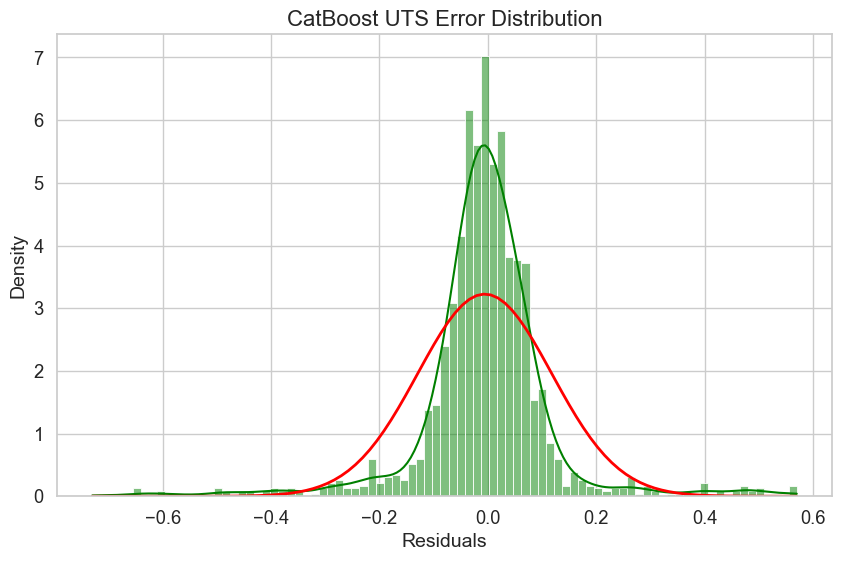

{'learn': {'RMSE': [0.45393705576308757, 0.4534697187514239, 0.4465272458829307, 0.44107290367578045, 0.43443021931524317, 0.42926432053533475, 0.4227630720854999, 0.41777691265297917, 0.417247973496652, 0.4123519355639631, 0.41194334352963546, 0.4071890246348075, 0.40152377996375044, 0.3953104412785481, 0.39085556176980024, 0.38487358233417496, 0.38453385751794084, 0.3801316487456995, 0.37463413682332497, 0.3705316920906724, 0.3664138067568826, 0.36238078265212664, 0.35843438852277426, 0.35296558005291, 0.3492352555434782, 0.3488497277241699, 0.34337689794305476, 0.34304950940783707, 0.33806694738029397, 0.3344899282357441, 0.3310457638177368, 0.32757499551413927, 0.32727423481761714, 0.3222463479230997, 0.3218811828561934, 0.31749740122162207, 0.3143903259190931, 0.3112043734701324, 0.30806822102947296, 0.30349661956147855, 0.2994716755568873, 0.29531158858021034, 0.29245222511283203, 0.2895511508134646, 0.28933222937802067, 0.28652119780140256, 0.2836707688285546, 0.2808966828994985

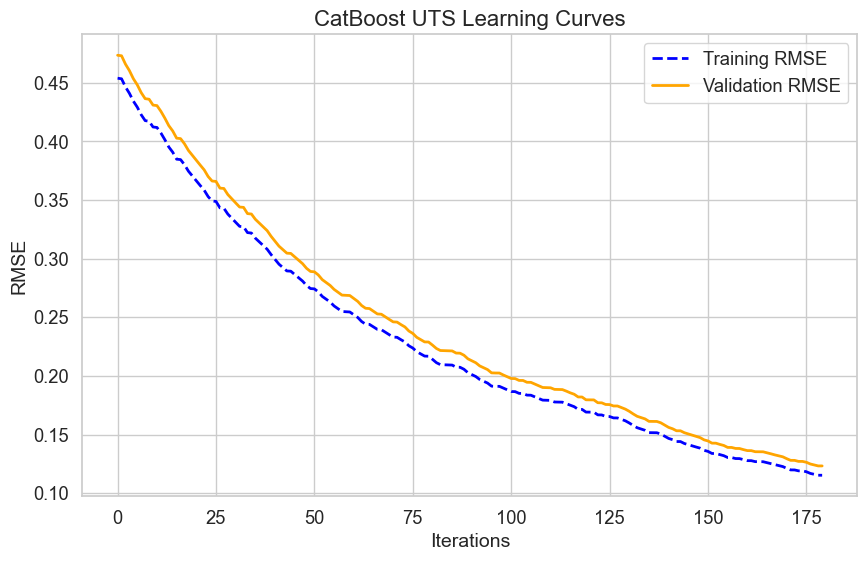

0:	learn: 0.4568303	test: 0.4764620	best: 0.4764620 (0)	total: 3.71ms	remaining: 664ms
50:	learn: 0.3513839	test: 0.3684166	best: 0.3684166 (50)	total: 117ms	remaining: 297ms
100:	learn: 0.2821787	test: 0.2970289	best: 0.2970289 (100)	total: 237ms	remaining: 185ms
150:	learn: 0.2333236	test: 0.2461499	best: 0.2461499 (150)	total: 341ms	remaining: 65.5ms
179:	learn: 0.2111316	test: 0.2230105	best: 0.2230105 (179)	total: 399ms	remaining: 0us

bestTest = 0.2230104906
bestIteration = 179

0:	learn: 0.4453231	test: 0.4648421	best: 0.4648421 (0)	total: 2.96ms	remaining: 531ms
50:	learn: 0.1430980	test: 0.1521296	best: 0.1521296 (50)	total: 134ms	remaining: 340ms
100:	learn: 0.0694841	test: 0.0756694	best: 0.0756694 (100)	total: 271ms	remaining: 212ms
150:	learn: 0.0410441	test: 0.0453279	best: 0.0453279 (150)	total: 415ms	remaining: 79.8ms
179:	learn: 0.0321516	test: 0.0356797	best: 0.0356797 (179)	total: 509ms	remaining: 0us

bestTest = 0.03567970101
bestIteration = 179

0:	learn: 0.4311986

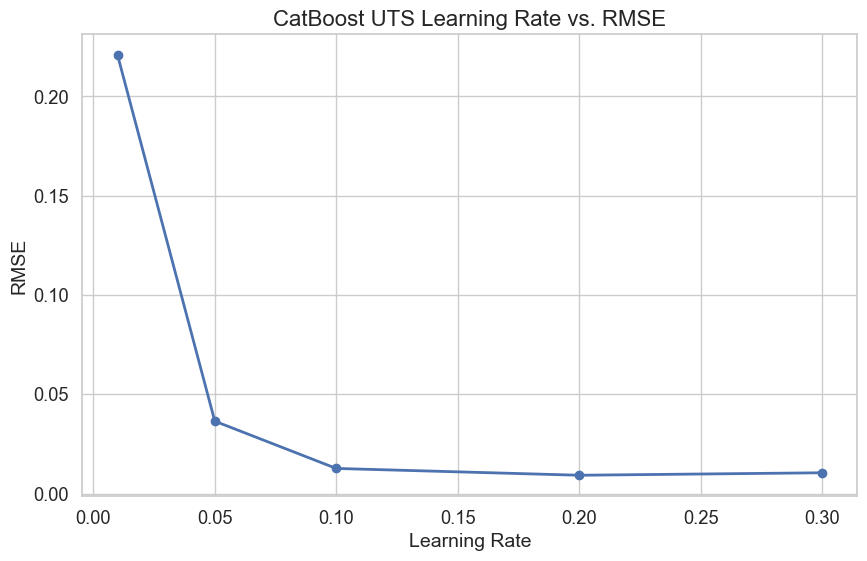

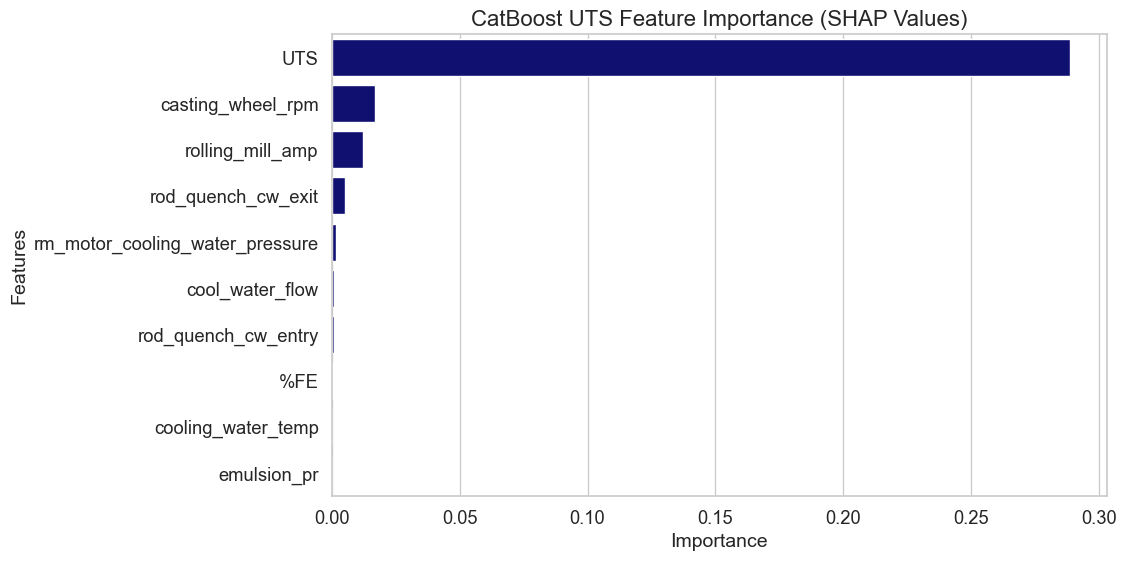

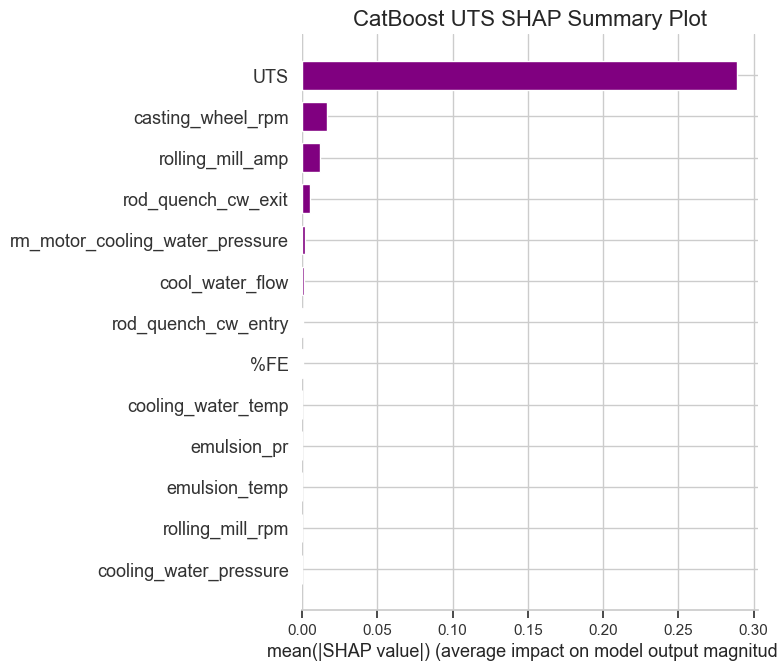

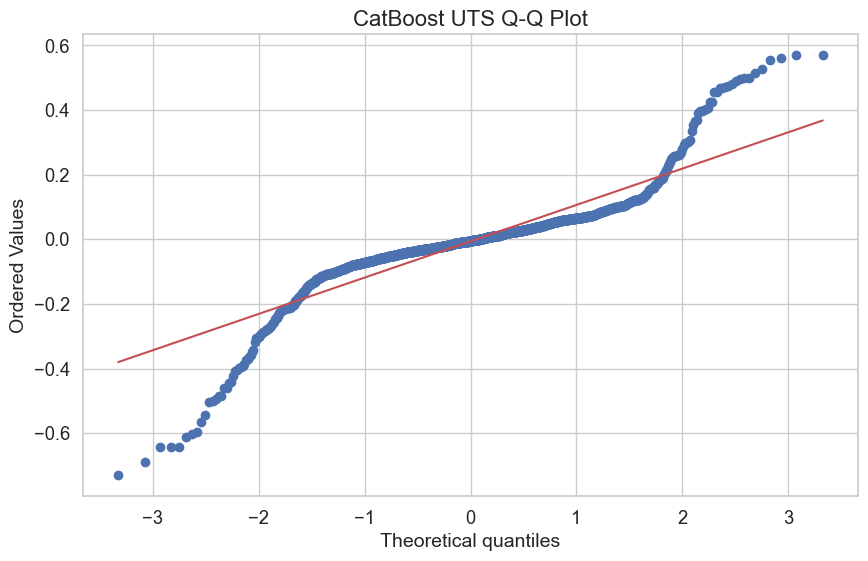

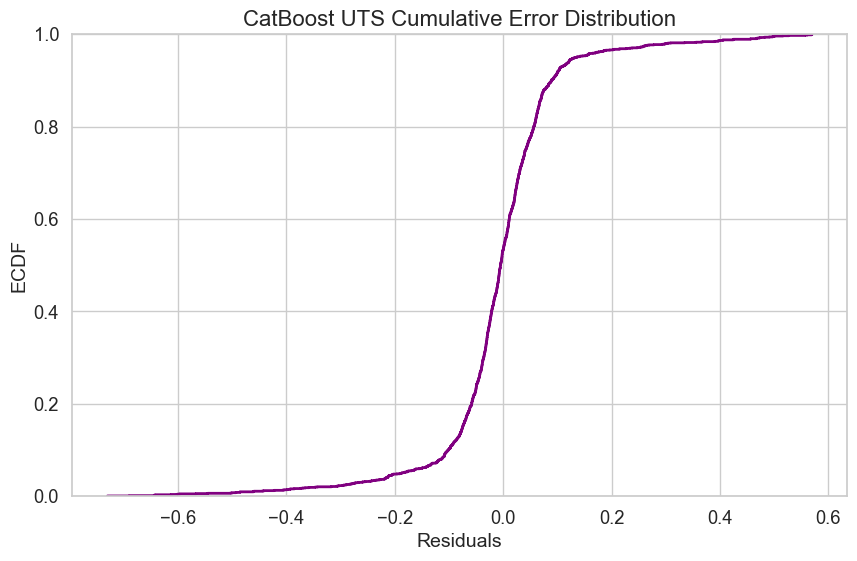

In [1]:
import pandas as pd
import numpy as np
import catboost as cb
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import scipy.stats as stats

# ✅ Load dataset
file_path = "processed_dataset.csv"
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()

# ✅ Remove duplicate rows
df.drop_duplicates(inplace=True)

# ✅ Handle missing values
df.fillna(df.median(numeric_only=True), inplace=True)
df.fillna(df.mode().iloc[0], inplace=True)

# ✅ Define columns to exclude
columns_to_exclude = ["Conductivity", "elongation", "Grade", "Grade_encoded"]
X = df.drop(columns=columns_to_exclude, errors="ignore")
y = df["UTS"]

# ✅ Normalize numeric features
scaler = MinMaxScaler()
X[X.select_dtypes(include=["float64", "int64"]).columns] = scaler.fit_transform(
    X.select_dtypes(include=["float64", "int64"])
)

# ✅ Encode categorical features
for col in X.select_dtypes(include="object").columns:
    X[col] = X[col].astype("category")

# ✅ Train / Validation / Test Split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)  
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# ✅ Define CatBoost hyperparameters for UTS
params_uts = {
    "iterations": 180,
    "learning_rate": 0.02,
    "depth": 2,
    "l2_leaf_reg": 18,
    "subsample": 0.5,
    "colsample_bylevel": 0.5,
    "random_seed": 42,
    "loss_function": "RMSE",
    "verbose": 50
}

# ✅ Train CatBoost model for UTS
cat_model_uts = cb.CatBoostRegressor(**params_uts)
cat_model_uts.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=50)

# ✅ Predict on Test set
y_pred = cat_model_uts.predict(X_test)

# ✅ Metrics
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

# ✅ Print Final Metrics
print("\n🔹 CatBoost UTS Regression Metrics:")
print(f"✅ R²: {r2:.4f}")
print(f"✅ RMSE: {rmse:.4f}")
print(f"✅ MAE: {mae:.4f}")
print(f"✅ MAPE: {mape:.2f}%")

# ✅ Residuals
residuals_uts = y_test - y_pred

# ✅ Visualizations
output_dir_uts = "catboost_uts_plots"
os.makedirs(output_dir_uts, exist_ok=True)

# Enhanced global styling
sns.set(style="whitegrid", font_scale=1.2, rc={"font.family": "Arial", "axes.titlesize": 16, "axes.labelsize": 14})

# High-quality DPI
dpi = 400

# 1. Actual vs. Predicted
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.4, color="royalblue", s=50)
sns.regplot(x=y_test, y=y_pred, scatter=False, color="red", lowess=True, line_kws={'linewidth':2})
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1)
plt.title("CatBoost UTS Actual vs. Predicted")
plt.xlabel("Actual UTS")
plt.ylabel("Predicted UTS")
plt.savefig(f"{output_dir_uts}/CatBoost_UTS_Actual_vs_Predicted.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 2. Residual Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals_uts, alpha=0.4, color="darkorange", s=50)
sns.regplot(x=y_pred, y=residuals_uts, scatter=False, color="blue", lowess=True, line_kws={'linewidth':2})
plt.axhline(0, color="black", linestyle='--')
plt.title("CatBoost UTS Residual Plot")
plt.xlabel("Predicted UTS")
plt.ylabel("Residuals")
plt.savefig(f"{output_dir_uts}/CatBoost_UTS_Residual_Plot.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 3. Error Distribution
plt.figure(figsize=(10, 6))
sns.histplot(residuals_uts, kde=True, color="green", stat="density")
x_vals = np.linspace(residuals_uts.min(), residuals_uts.max(), 100)
plt.plot(x_vals, stats.norm.pdf(x_vals, residuals_uts.mean(), residuals_uts.std()), color="red", linewidth=2)
plt.title("CatBoost UTS Error Distribution")
plt.xlabel("Residuals")
plt.ylabel("Density")
plt.savefig(f"{output_dir_uts}/CatBoost_UTS_Error_Distribution.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 4. Learning Curves
# ✅ Learning Curves
results_uts = cat_model_uts.get_evals_result()

# Print out the structure of the evaluation results to identify the correct keys
print(results_uts)

# Adjust to correct keys for plotting based on the actual structure of results_uts
plt.figure(figsize=(10, 6))
plt.plot(results_uts['learn']['RMSE'], '--', label='Training RMSE', color='blue', linewidth=2)
plt.plot(results_uts['validation']['RMSE'], '-', label='Validation RMSE', color='orange', linewidth=2)
plt.title("CatBoost UTS Learning Curves")
plt.xlabel("Iterations")
plt.ylabel("RMSE")
plt.legend()
plt.savefig(f"{output_dir_uts}/CatBoost_UTS_Learning_Curves.png", dpi=dpi, bbox_inches='tight')
plt.show()


# 5. Hyperparameter vs. Error Plot
learning_rates = [0.01, 0.05, 0.1, 0.2, 0.3]
errors_uts = []
for lr in learning_rates:
    temp_params = params_uts.copy()
    temp_params["learning_rate"] = lr
    model = cb.CatBoostRegressor(**temp_params)
    model.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=50)
    y_pred_temp = model.predict(X_test)
    rmse_uts = np.sqrt(mean_squared_error(y_test, y_pred_temp))
    errors_uts.append(rmse_uts)

plt.figure(figsize=(10, 6))
plt.plot(learning_rates, errors_uts, marker='o', linewidth=2)
plt.title("CatBoost UTS Learning Rate vs. RMSE")
plt.xlabel("Learning Rate")
plt.ylabel("RMSE")
plt.savefig(f"{output_dir_uts}/CatBoost_UTS_Hyperparameter_vs_Error.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 6. Feature Importance
# ✅ Feature Importance
# ✅ Feature Importance using SHAP
import shap

# Create a SHAP explainer for the trained model
explainer_uts = shap.TreeExplainer(cat_model_uts)

# Calculate SHAP values for the test set
shap_values_uts = explainer_uts.shap_values(X_test)

# Create a DataFrame to store the feature names and their importance scores based on SHAP values
shap_importance = np.abs(shap_values_uts).mean(axis=0)
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": shap_importance
})

# Sort the DataFrame by importance in descending order
importance_df = importance_df.sort_values(by="Importance", ascending=False).head(10)

# Plotting feature importance using SHAP values
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=importance_df, color="navy")
plt.title("CatBoost UTS Feature Importance (SHAP Values)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.savefig(f"{output_dir_uts}/CatBoost_UTS_Feature_Importance_SHAP.png", dpi=dpi, bbox_inches='tight')
plt.show()


# 7. SHAP Summary Plot
explainer_uts = shap.TreeExplainer(cat_model_uts)
shap_values_uts = explainer_uts.shap_values(X_test)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_uts, X_test, plot_type="bar", show=False, color='purple')
plt.title("CatBoost UTS SHAP Summary Plot")
plt.savefig(f"{output_dir_uts}/CatBoost_UTS_SHAP_Summary_Plot.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 8. Q-Q Plot
plt.figure(figsize=(10, 6))
stats.probplot(residuals_uts, dist="norm", plot=plt)
plt.title("CatBoost UTS Q-Q Plot")
plt.savefig(f"{output_dir_uts}/CatBoost_UTS_QQ_Plot.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 9. Cumulative Error Distribution
plt.figure(figsize=(10, 6))
sns.ecdfplot(residuals_uts, color="purple", linewidth=2)
plt.title("CatBoost UTS Cumulative Error Distribution")
plt.xlabel("Residuals")
plt.ylabel("ECDF")
plt.savefig(f"{output_dir_uts}/CatBoost_UTS_Cumulative_Error_Distribution.png", dpi=dpi, bbox_inches='tight')
plt.show()